In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
import scipy.stats as stats

Import all data, construct the respective X and y matrices and make and group individuals 

In [2]:
df = pd.read_csv("HR_data.csv")

In [3]:
X_ = df.drop(columns=['Unnamed: 0', 'Round', 'Phase', 'Individual', 'Puzzler', 'Frustrated', 'Cohort'])
y_ = df['Frustrated']

In [4]:
X = X_.values
y = y_.values
groups = df['Individual'].values

ANN Model architecture:

In [5]:
def get_model(input_dim, hidden_dim, output_dim):
    model = torch.nn.Sequential(
        torch.nn.Linear(in_features=input_dim, out_features=hidden_dim, bias=True),
        torch.nn.Tanh(),
        torch.nn.Linear(in_features=hidden_dim, out_features=output_dim, bias=True),
        torch.nn.ReLU()
        
    )
    return model

Group splits:

In [6]:
outer_fold_splits = GroupKFold(n_splits=7)
inner_fold_splits = GroupKFold(n_splits=4)

ANN model:

In [ ]:
hidden_dims = [25, 40, 50]
outer_fold_rmses = []
train_rmses = []
for fold, (train_idx, test_idx) in enumerate(outer_fold_splits.split(X, y, groups)):
    #use mask to extract outer and inner train&test sets:
    X_outer_train = X[train_idx]
    X_outer_test = X[test_idx]
    y_outer_train = y[train_idx]
    y_outer_test = y[test_idx]

    inner_groups = groups[train_idx]
    #initialise best hyperparameter to NULL and its RMSE to infinity:
    best_inner_rmse = float('inf')
    best_hidden_dim = None
    #INNER CV:
    for each_hidden_dim in hidden_dims:
        rmses_inner = []
        for inner_train_idx, inner_val_idx in inner_fold_splits.split(X_outer_train, y_outer_train, inner_groups):
            #making inner validation and train sets:
            X_inner_train = X_outer_train[inner_train_idx]
            y_inner_train = y_outer_train[inner_train_idx]
            X_inner_val = X_outer_train[inner_val_idx]
            y_inner_val = y_outer_train[inner_val_idx]

            #normalizing the inner train and validation sets, using only the inner train set(that's why inner_train_normalised uses fit_transform whereas inner_val_normalised uses just transform)
            scale = StandardScaler()
            X_inner_train_normalised = scale.fit_transform(X_inner_train)
            X_inner_val_normalised = scale.transform(X_inner_val)

            #Training with the hidden dim:

            #converting values to tensors 
            X_train_inner = torch.tensor(X_inner_train_normalised, dtype=torch.float32)
            X_test_inner = torch.tensor(X_inner_val_normalised, dtype=torch.float32)
            y_inner_train = torch.tensor(y_inner_train, dtype=torch.float32).view(-1, 1)
            y_inner_val = torch.tensor(y_inner_val, dtype=torch.float32).view(-1, 1)


            torch.manual_seed(10) #setting a seed for reproductivity
            ANNmodel = get_model(X.shape[1], each_hidden_dim, 1) #defining ANN model and setting model parameters
            lr = 1e-3 
            criterion = torch.nn.MSELoss() # to measure loss
            optimizer = torch.optim.SGD(ANNmodel.parameters(), lr=lr)


            
            epochs = 4000
            #train model on inner fold train set:
            for i in range(epochs):
                ANNmodel.train()
                optimizer.zero_grad()

                predicted_outputs = ANNmodel(X_train_inner)
                
                loss = criterion(predicted_outputs, y_inner_train)
                
                loss.backward()
                optimizer.step()


            #test model on inner validation set:
            ANNmodel.eval()

            with torch.no_grad():
                val_outputs = ANNmodel(X_test_inner)
                val_loss = criterion(val_outputs, y_inner_val)
                rmse = np.sqrt(val_loss)
                rmses_inner.append(rmse)
        
        #select the best hidden dim as the one which gives least error on each inner fold's validation set:
        mean_inner_rmse = np.mean(rmses_inner)
        if mean_inner_rmse < best_inner_rmse:
            best_inner_rmse = mean_inner_rmse
            best_hidden_dim = each_hidden_dim
    print(f'fold {fold+1}: best hiden dim is : {best_hidden_dim}')

    #TESTING THE BEST HIDDEN DIM ON OUTER TEST SET:
    #standardising the outer train and test sets as before:
    scaler = StandardScaler()
    X_outer_train_normalised = scaler.fit_transform(X_outer_train)
    X_outer_test_normalised = scaler.transform(X_outer_test)

    #converting to tensor values as before:
    X_train_outer = torch.tensor(X_outer_train_normalised, dtype=torch.float32)
    X_test_outer = torch.tensor(X_outer_test_normalised, dtype=torch.float32)
    y_train_outer = torch.tensor(y_outer_train, dtype=torch.float32).view(-1, 1)
    y_test_outer = torch.tensor(y_outer_test, dtype=torch.float32).view(-1, 1)


    main_model = get_model(X.shape[1], best_hidden_dim, 1) #defining model with the optimal number of hidden dimmensions
    lr = 1e-3
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr)
    
    
    outer_fold_train_rmses = []
    #train final model on outer train set:
    epochs = 4000
    for i in range(epochs):
        main_model.train()
        optimizer.zero_grad()

        pred_output = main_model(X_train_outer)
        outer_loss = criterion(pred_output, y_train_outer)
        rmses_train_outer = np.sqrt(outer_loss.item())
        outer_fold_train_rmses.append(rmses_train_outer)
        
        outer_loss.backward()
        optimizer.step()

    train_rmses.append(outer_fold_train_rmses)
    #test final model on outer test set:
    main_model.eval()
    with torch.no_grad():
        test_output = main_model(X_test_outer)
        loss_outer_fold = criterion(test_output, y_test_outer)
        rmse_outer = np.sqrt(loss_outer_fold)
        print(f'outer fold rmse for fold {fold+1} is : {rmse_outer}')
        outer_fold_rmses.append(rmse_outer)


C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __a

fold 1: best hiden dim is : 50


C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:107: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse_outer = np.sqrt(loss_outer_fold)


outer fold rmse for fold 1 is : 2.1900312900543213


C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __a

...

C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:107: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse_outer = np.sqrt(loss_outer_fold)


outer fold rmse for fold 6 is : 2.1119189262390137


C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = np.sqrt(val_loss)
C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:60: DeprecationWarning: __a

fold 7: best hiden dim is : 50
outer fold rmse for fold 7 is : 1.6450543403625488


C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2142638824.py:107: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse_outer = np.sqrt(loss_outer_fold)


In [ ]:
print(np.mean(train_rmses)) #mean over all folds:

1.8642198887958383


ANN train figures for all folds and average over all folds:

Text(0, 0.5, 'RMSE')

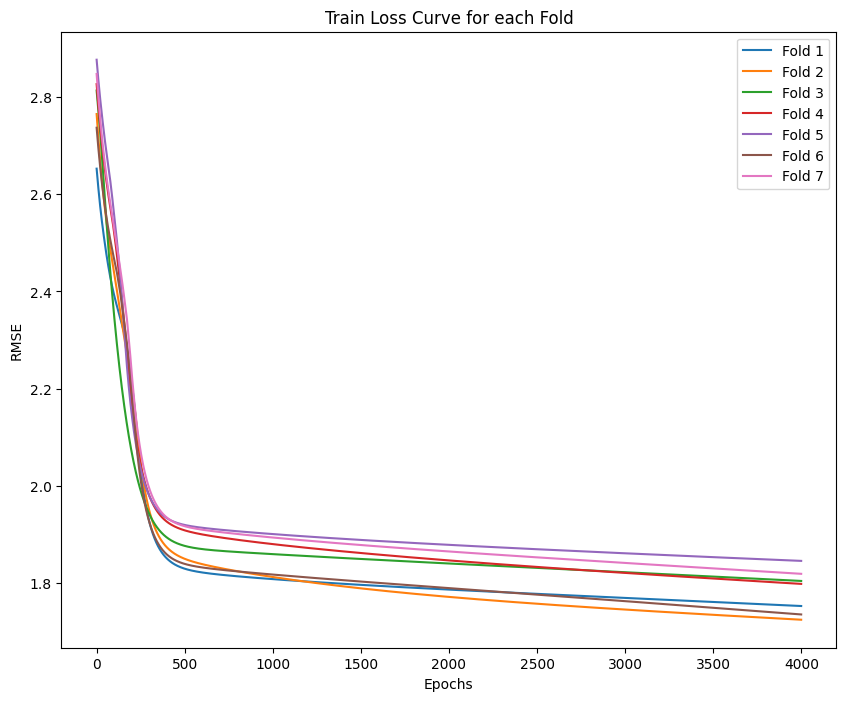

In [9]:
fig, ax = plt.subplots(figsize=(10,8))
folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Fold 6', 'Fold 7']

for i, each_fold in enumerate(train_rmses):
    ax.plot(range(4000), each_fold, label=folds[i])

ax.legend()
ax.set_title("Train Loss Curve for each Fold")
ax.set_xlabel("Epochs")
ax.set_ylabel("RMSE")

Text(0.5, 1.0, 'Average Train Loss')

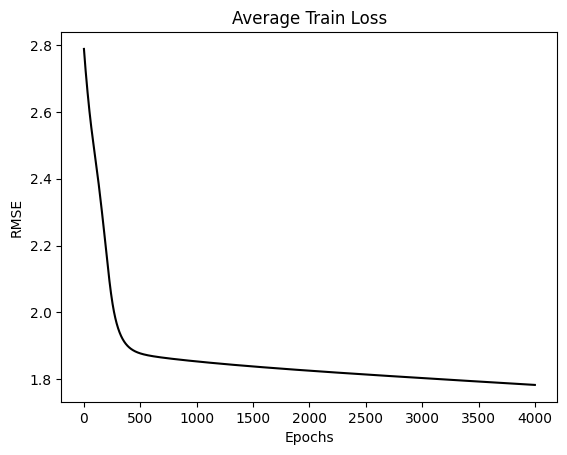

In [10]:
avg_train_rmse_over_all_folds = np.mean(train_rmses, axis=0)
plt.plot(range(4000), avg_train_rmse_over_all_folds, color="black")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.title("Average Train Loss")

Visualising the outer and inner test folds:

In [11]:
for fold, (train_idx,test_idx) in enumerate(outer_fold_splits.split(X, y, groups)):
    print(f'Fold {fold+1}: Test individuals = {np.unique(groups[test_idx])}')

Fold 1: Test individuals = [ 7 14]
Fold 2: Test individuals = [ 6 13]
Fold 3: Test individuals = [ 5 12]
Fold 4: Test individuals = [ 4 11]
Fold 5: Test individuals = [ 3 10]
Fold 6: Test individuals = [2 9]
Fold 7: Test individuals = [1 8]


In [12]:
for fold, (train_idx,test_idx) in enumerate(inner_fold_splits.split(X, y, groups)):
    print(f'Fold {fold+1}: Test individuals = {np.unique(groups[test_idx])}')

Fold 1: Test individuals = [ 2  6 10 14]
Fold 2: Test individuals = [ 1  5  9 13]
Fold 3: Test individuals = [ 4  8 12]
Fold 4: Test individuals = [ 3  7 11]


In [ ]:
outer_fold_rmses_non_tensor_list = [each.item() for each in outer_fold_rmses] # Turninng the tensor items to intigers for easier acess

Construct X and y matricies for the Ridge Regression Model:

In [14]:
X_LinReg = df.drop(columns=['Unnamed: 0', 'Round', 'Phase', 'Individual', 'Puzzler', 'Frustrated', 'Cohort'])
y_linreg = df['Frustrated']

In [15]:
X_LinReg = X_LinReg.values
y_linreg = y_linreg.values
groups = df['Individual'].values

Ridge Regression Model:

In [ ]:
lin_reg_test_rmses = []
lin_reg_train_rmses= []
lambs = [0.01, 0.1, 1, 10, 100, 1000] #Different regularization strengths
outer_train_rmses = []


for fold, (train_idx, test_idx) in enumerate(outer_fold_splits.split(X, y, groups)):
    #Make outer train and test sets using the masks: 
    X_outer_train = X_LinReg[train_idx]
    X_outer_test = X_LinReg[test_idx]
    y_outer_train = y[train_idx]
    y_outer_test = y[test_idx]
    #initialise best hyperparameter to NULL and its RMSE to infinity:
    inner_groups = groups[train_idx]
    best_inner_rmse = float('inf')
    best_lamb = None

    #INNER CV:
    for each_lamb in lambs:
        rmeses_internal = []

        for inner_train_idx, inner_val_idx in inner_fold_splits.split(X_outer_train, y_outer_train, inner_groups):
            #construct inner train and validation sets using the inner split mask:
            X_inner_train = X_outer_train[inner_train_idx]
            y_inner_train = y_outer_train[inner_train_idx]
            X_inner_val = X_outer_train[inner_val_idx]
            y_inner_val = y_outer_train[inner_val_idx]

            #standardize the inner train and validation sets, using only the mean and standard deviation of the train set:
            X_inner_train_mean = X_inner_train.mean(axis=0)
            X_inner_train_std = X_inner_train.std(axis=0)

            X_inner_train_normalized = (X_inner_train-X_inner_train_mean)/X_inner_train_std
            X_inner_val_normalized = (X_inner_val-X_inner_train_mean)/X_inner_train_std

            #constructing the X_tilde matrix and removing setting the value of the first entry of Identity matrix to 0, to not regularize the bias term: 
            X_tilde_inner = np.column_stack([np.ones(len(X_inner_train_normalized)), X_inner_train_normalized])
            I_inner = np.eye(X_tilde_inner.shape[1])
            I_inner[0,0] = 0
            #calculating the optimal weight(w_star):
            w_star = np.linalg.inv(X_tilde_inner.T@X_tilde_inner+each_lamb*I_inner) @ X_tilde_inner.T@y_inner_train

            ##TRAIN ON INNER:
            y_est_train_inner = X_tilde_inner@w_star
            rmse_train_inner = np.sqrt(np.mean((y_est_train_inner-y_inner_train)**2))
            lin_reg_train_rmses.append(rmse_train_inner)


            ##TEST ON VALIDATION SET 
            X_tilde_val = np.column_stack([np.ones(len(X_inner_val_normalized)), X_inner_val_normalized])
            y_est_val = X_tilde_val@w_star

            rmse_lin_reg_internal = np.sqrt(np.mean((y_est_val-y_inner_val)**2))

            rmeses_internal.append(rmse_lin_reg_internal)
        #Choose best hyperparamter as the one that has the least rmse:
        mean_inner_rmse = np.mean(rmeses_internal)
        if mean_inner_rmse < best_inner_rmse:
            best_inner_rmse = mean_inner_rmse
            best_lamb = each_lamb
    print(f'fold {fold+1}: best lambda is  : {best_lamb}')

    # BEST LAMBDA ON OUTER TRAIN SET:

    #standardise the outer train and test sets using the mean and std of the train set only:
    X_outer_train_mean = X_outer_train.mean(axis=0)
    X_outer_train_std = X_outer_train.std(axis=0)

    X_outer_train_normalized = (X_outer_train-X_outer_train_mean)/X_outer_train_std
    X_outer_test_normalized = (X_outer_test-X_outer_train_mean)/X_outer_train_std

    #construct the X_tilde matrix, reset first entry of the identity matrix and calculate optimal weight(w_star):
    X_tilde_outer_train = np.column_stack([np.ones(len(X_outer_train_normalized)), X_outer_train_normalized])
    I_outer = np.eye(X_tilde_outer_train.shape[1])
    I_outer[0,0] = 0
    w_star_o = np.linalg.inv(X_tilde_outer_train.T@X_tilde_outer_train+best_lamb*I_outer) @ X_tilde_outer_train.T@y_outer_train
    #calculate train error:
    y_est_train_outer = X_tilde_outer_train@w_star_o
    rmse_train_outer = np.sqrt(np.mean((y_est_train_outer-y_outer_train)**2))
    outer_train_rmses.append(rmse_train_outer)

    #TEST BEST LAMDA MODEL ON OUTER TEST SET:
    X_tilde_outer_test = np.column_stack([np.ones(len(X_outer_test_normalized)), X_outer_test_normalized])
    y_est_test_outer = X_tilde_outer_test@w_star_o

    #Calculate error and append it to the list of all outer fold errors:
    rmse_test_outer = np.sqrt(np.mean((y_est_test_outer-y_outer_test)**2))

    print(f'for fold {fold+1} the RMSE  is : {rmse_test_outer}')
    lin_reg_test_rmses.append(rmse_test_outer)

    

print(lin_reg_test_rmses)
print(np.mean(lin_reg_test_rmses))

fold 1: best lambda is  : 1000
for fold 1 the RMSE  is : 2.3332225240144977
fold 2: best lambda is  : 100
for fold 2 the RMSE  is : 2.1253034981806183
fold 3: best lambda is  : 1000
for fold 3 the RMSE  is : 2.000801403009589
fold 4: best lambda is  : 1000
for fold 4 the RMSE  is : 1.5859334691197617
fold 5: best lambda is  : 1000
for fold 5 the RMSE  is : 1.6957057863025293
fold 6: best lambda is  : 1000
for fold 6 the RMSE  is : 2.120916252508002
fold 7: best lambda is  : 1000
for fold 7 the RMSE  is : 1.6640239051617296
[np.float64(2.3332225240144977), np.float64(2.1253034981806183), np.float64(2.000801403009589), np.float64(1.5859334691197617), np.float64(1.6957057863025293), np.float64(2.120916252508002), np.float64(1.6640239051617296)]
1.932272405470961


Construct table of outer fold RMSE values for both models:

In [ ]:
table = pd.DataFrame({'ANN_OuterFold_RMSEs':outer_fold_rmses_non_tensor_list, 'LinReg_OuterFold_RMSEs':lin_reg_test_rmses})
table.index = [1, 2, 3, 4, 5, 6, 7]
table

,ANN_OuterFold_RMSEs,LinReg_OuterFold_RMSEs
1,2.190031,2.333223
2,2.251710,2.125303
3,1.909721,2.000801
4,1.738208,1.585933
5,1.536450,1.695706
6,2.111919,2.120916
7,1.645054,1.664024


Calculate differences of the RMSE values and add it to a new column in the table:

In [18]:
table['differences'] = table['ANN_OuterFold_RMSEs']-table['LinReg_OuterFold_RMSEs']

In [19]:
table

,ANN_OuterFold_RMSEs,LinReg_OuterFold_RMSEs,differences
1,2.190031,2.333223,-0.143191
2,2.251710,2.125303,0.126407
3,1.909721,2.000801,-0.091081
4,1.738208,1.585933,0.152275
5,1.536450,1.695706,-0.159256
6,2.111919,2.120916,-0.008997
7,1.645054,1.664024,-0.018970


Hypothesis testing on the differences:

In [20]:
paired_ttest = stats.ttest_1samp(table['differences'], popmean=0)
print(paired_ttest.statistic, paired_ttest.pvalue, paired_ttest.df)

-0.43865046934939583 0.6762687831475306 6


In [21]:
CI = paired_ttest.confidence_interval(0.95)
CI

ConfidenceInterval(low=np.float64(-0.13420875588711711), high=np.float64(0.09340510847145758))

In [22]:
table_means = table.mean(axis=0)

In [23]:
table_means

ANN_OuterFold_RMSEs       1.911871
LinReg_OuterFold_RMSEs    1.932272
differences              -0.020402
dtype: float64

Plotting the boxplot of both models' RMSE values:

C:\Users\PC\AppData\Local\Temp\ipykernel_10592\2638936573.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lin_reg_test_rmses, outer_fold_rmses_non_tensor_list], labels=['Ridge Regression Model', 'Artificial Neural Network Model'])


{'whiskers': [<matplotlib.lines.Line2D at 0x1b556f25b90>,
 'caps': [<matplotlib.lines.Line2D at 0x1b556f26ed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b556f25290>,
 'medians': [<matplotlib.lines.Line2D at 0x1b556f27890>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b556f38450>,
 'means': []}

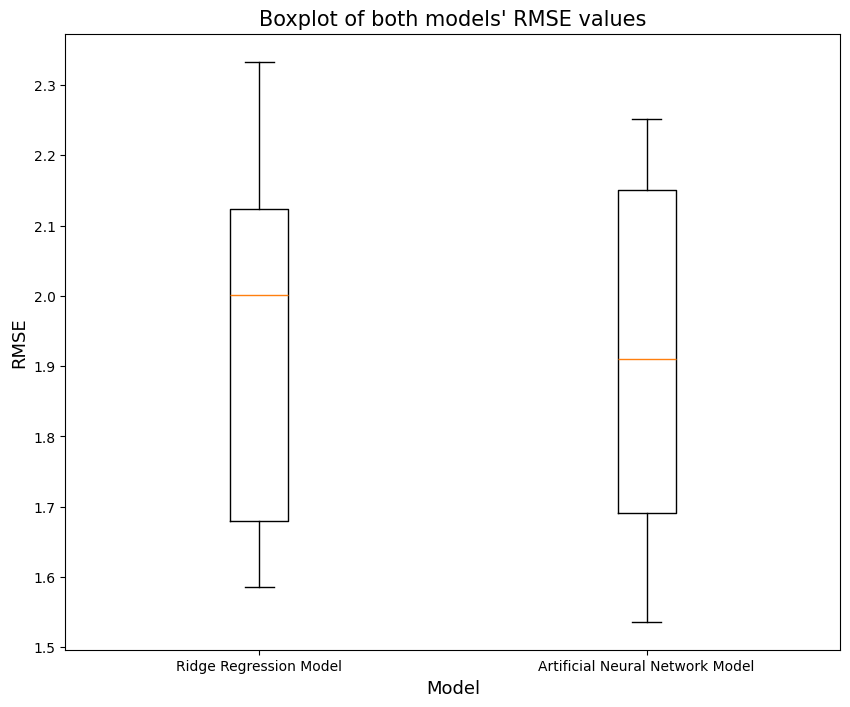

In [ ]:
plt.figure(figsize=(10,8))
plt.title("Boxplot of both models' RMSE values", fontsize=15)
plt.ylabel("RMSE", fontsize=13)
plt.xlabel("Model", fontsize=13)
plt.boxplot([lin_reg_test_rmses, outer_fold_rmses_non_tensor_list], labels=['Ridge Regression Model', 'Artificial Neural Network Model'])

Plotting barchart of both models' RMSE values on the same plot for better comparison:

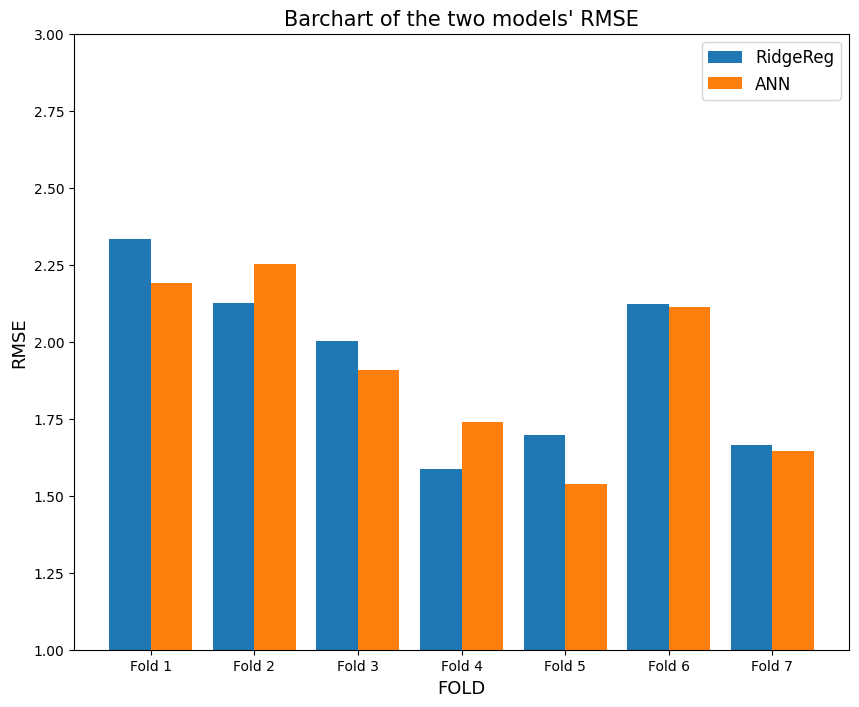

In [55]:
folds_str = ['Fold 1', 'Fold 2', 'Fold 3','Fold 4', 'Fold 5', 'Fold 6', 'Fold 7']

width, x_axis = 0.4, np.arange(7)
fig, ax = plt.subplots(figsize=(10,8))


ax.bar(x_axis-width/2, lin_reg_test_rmses, width=width, label='RidgeReg')
ax.bar(x_axis+width/2, outer_fold_rmses_non_tensor_list, width=width, label='ANN')
ax.set_xticks(x_axis)
ax.set_ylim(1,3)
ax.set_xticklabels(folds_str)
ax.set_xlabel("FOLD", fontsize=13)
ax.set_ylabel("RMSE", fontsize=13)
ax.set_title("Barchart of the two models' RMSE", fontsize=15)
ax.legend(fontsize=12)

Both Boxplot and Barchart on the same plot:

C:\Users\PC\AppData\Local\Temp\ipykernel_10592\3079055553.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([lin_reg_test_rmses, outer_fold_rmses_non_tensor_list], labels=['Ridge Regression Model', 'Artificial Neural Network Model'])


{'whiskers': [<matplotlib.lines.Line2D at 0x1b557314290>,
 'caps': [<matplotlib.lines.Line2D at 0x1b557315610>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b55730f910>,
 'medians': [<matplotlib.lines.Line2D at 0x1b5573169d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b5573173d0>,
 'means': []}

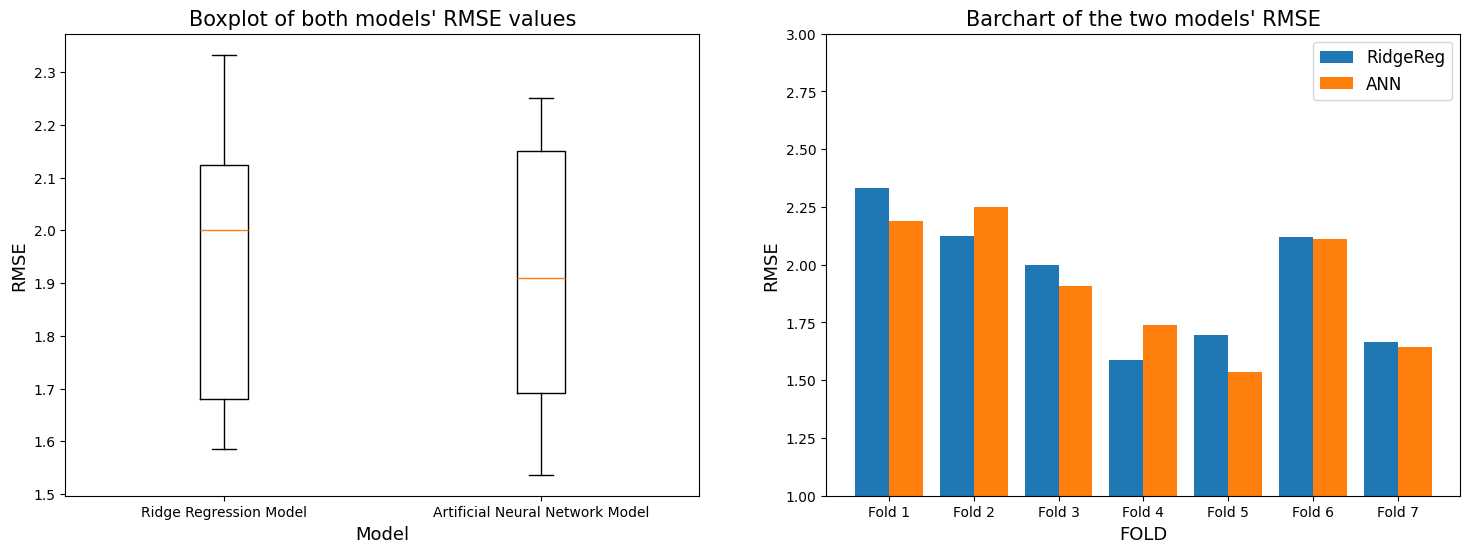

In [59]:
fig, axes = plt.subplots(1,2, figsize=(18, 6))
axes[1].bar(x_axis-width/2, lin_reg_test_rmses, width=width, label='RidgeReg')
axes[1].bar(x_axis+width/2, outer_fold_rmses_non_tensor_list, width=width, label='ANN')
axes[1].set_xticks(x_axis)

axes[1].set_xticklabels(folds_str)
axes[1].set_xlabel("FOLD", fontsize=13)
axes[1].set_ylabel("RMSE", fontsize=13)
axes[1].set_title("Barchart of the two models' RMSE", fontsize=15)
axes[1].set_ylim(1,3)
axes[1].legend(fontsize=12)

axes[0].set_title("Boxplot of both models' RMSE values", fontsize=15)
axes[0].set_ylabel("RMSE", fontsize=13)
axes[0].set_xlabel("Model", fontsize=13)
axes[0].boxplot([lin_reg_test_rmses, outer_fold_rmses_non_tensor_list], labels=['Ridge Regression Model', 'Artificial Neural Network Model'])

Calculation of interquartile range and standard deviations of the two models' performance:

In [27]:
iqr_lr = np.percentile(lin_reg_test_rmses, 75)-np.percentile(lin_reg_test_rmses, 25)
iqr_ann = np.percentile(outer_fold_rmses_non_tensor_list, 75)-np.percentile(outer_fold_rmses_non_tensor_list, 25)
print(iqr_lr)
print(iqr_ann)

0.4432450296121808
0.4593437910079956


In [28]:
print(np.std(lin_reg_test_rmses))
print(np.std(outer_fold_rmses_non_tensor_list))

0.26354083633069025
0.2605429398049838


In [29]:
print(np.mean(lin_reg_train_rmses))

1.861672217062964


In [30]:
np.mean(outer_fold_rmses)-np.mean(train_rmses)

np.float64(0.04765047157861235)

In [31]:
np.std(outer_fold_rmses_non_tensor_list)-np.std(lin_reg_test_rmses)

np.float64(-0.0029978965257064782)

In [32]:
table_means['LinReg_OuterFold_RMSEs']-np.mean(lin_reg_train_rmses)

np.float64(0.07060018840799698)

Making the correlation matrix of all 6 attributes and Frustration level:

In [33]:
vars_with_frust = df.drop(columns=['Round',	'Phase',	'Individual',	'Puzzler',	'Cohort','Unnamed: 0'])

In [34]:
corr_mat_main = vars_with_frust.corr()

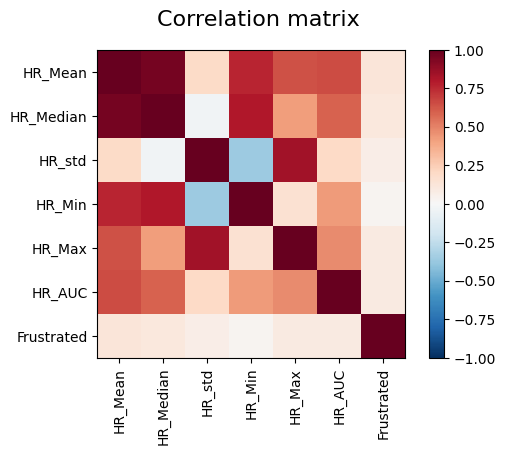

In [35]:
fig = plt.figure(figsize=(6, 4))
fig.suptitle('Correlation matrix', fontsize=16)
# Plot correlation matrix and set colorbar min and max to -1 and 1 since thats the range of the correlation coefficients
plt.imshow(corr_mat_main, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(ticks=np.arange(corr_mat_main.shape[1]), labels=list(corr_mat_main.columns), rotation=90)
plt.yticks(ticks=np.arange(corr_mat_main.shape[1]), labels=list(corr_mat_main.columns))
plt.grid(False)
plt.show()

QQ-plot of differences of RMSE values of both models, to check for normality:

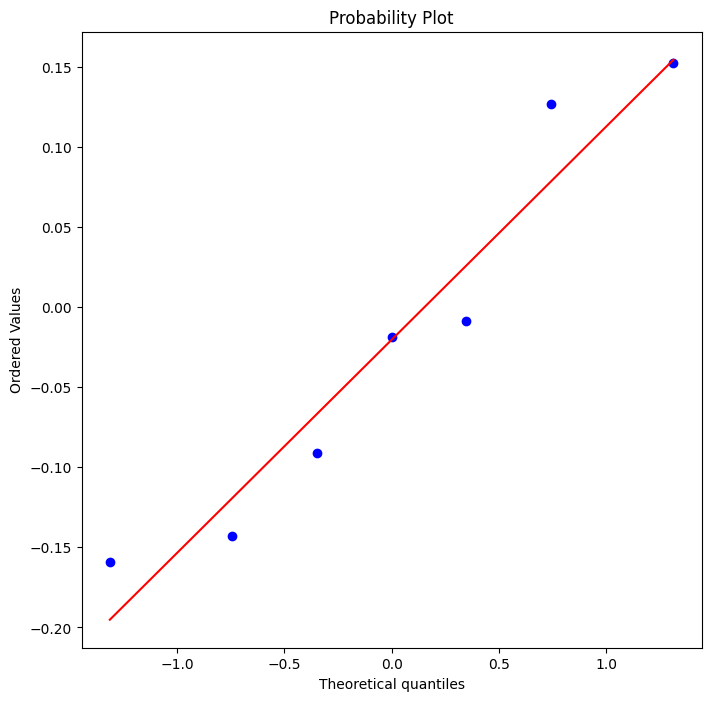

In [45]:
plt.figure(figsize=(8,8))
stats.probplot(table['differences'], dist='norm', plot=plt)
plt.show()

Confidence intervals of each model's average to assess the generalizability of the models(by seeing whether they overlap):

In [ ]:
ANN_ttest = stats.ttest_1samp(table['ANN_OuterFold_RMSEs'], popmean=np.mean(table['ANN_OuterFold_RMSEs']))
ANN_ttest.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(1.651601842520895), high=np.float64(2.1721393210053677))

In [44]:
RidgeReg_ttest = stats.ttest_1samp(table['LinReg_OuterFold_RMSEs'], popmean=np.mean(table['LinReg_OuterFold_RMSEs']))
RidgeReg_ttest.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(1.6690089247488429), high=np.float64(2.195535886193079))